# SETUP

In [12]:
pip install pandas requests matplotlib seaborn jupyter

Note: you may need to restart the kernel to use updated packages.


In [44]:
from src.fetch_data import get_stock_data, get_earnings_data

stock_df = get_stock_data("AAPL")
earn_df = get_earnings_data("AAPL")

,symbol,date,open,high,low,close,volume,change,changePercent,vwap
0,AAPL,2026-03-17,253.0785,255.1299,252.18,253.97,11475473,0.8915,0.352262,253.7600
1,AAPL,2026-03-16,252.1100,253.8900,249.88,252.82,32074209,0.7150,0.281620,252.1750
2,AAPL,2026-03-13,255.4800,256.3300,249.52,250.12,36929988,-5.3600,-2.100000,252.8625
3,AAPL,2026-03-12,258.6600,258.9500,254.18,255.76,40794020,-2.9000,-1.120000,256.8875
4,AAPL,2026-03-11,261.0900,262.1300,259.55,260.81,26218927,-0.2800,-0.107240,260.8950
...,...,...,...,...,...,...,...,...,...,...
1250,AAPL,2021-03-24,122.8200,122.9000,120.07,120.09,88530500,-2.7300,-2.220000,121.4700
1251,AAPL,2021-03-23,123.3300,124.2400,122.14,122.54,95467142,-0.7900,-0.640560,123.0625
1252,AAPL,2021-03-22,120.3300,123.8700,120.26,123.39,111912300,3.0600,2.540000,121.9625
1253,AAPL,2021-03-19,119.9000,121.4300,119.68,119.99,185549522,0.0900,0.075063,120.2500


# Cleaning

In [61]:
#convert datatype
stock_df['date'] = pd.to_datetime(stock_df['date'],errors="coerce")
earn_df['date'] = pd.to_datetime(earn_df['date'], format="%Y-%m-%d",errors="coerce")
earn_df['lastUpdated'] = pd.to_datetime(earn_df['lastUpdated'],errors="coerce")

stock_df.info()
earn_df.info()

#remove null 
stock_df.isnull().sum()
earn_df.isnull().sum()
earn_df=earn_df.dropna()

#sort date 
stock_df=stock_df.sort_values("date")
earn_df=earn_df.sort_values("date")

#create new varible to date open high low close collect
new_df=stock_df[['date', 'open' ,'high', 'low','close']]
new_df



<class 'pandas.core.frame.DataFrame'>
Index: 1255 entries, 1254 to 0
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   symbol         1255 non-null   object        
 1   date           1255 non-null   datetime64[ns]
 2   open           1255 non-null   float64       
 3   high           1255 non-null   float64       
 4   low            1255 non-null   float64       
 5   close          1255 non-null   float64       
 6   volume         1255 non-null   int64         
 7   change         1255 non-null   float64       
 8   changePercent  1255 non-null   float64       
 9   vwap           1255 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 107.9+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 102 entries, 122 to 1
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----      

,date,open,high,low,close
1254,2021-03-18,122.8800,123.1800,120.32,120.53
1253,2021-03-19,119.9000,121.4300,119.68,119.99
1252,2021-03-22,120.3300,123.8700,120.26,123.39
1251,2021-03-23,123.3300,124.2400,122.14,122.54
1250,2021-03-24,122.8200,122.9000,120.07,120.09
...,...,...,...,...,...
4,2026-03-11,261.0900,262.1300,259.55,260.81
3,2026-03-12,258.6600,258.9500,254.18,255.76
2,2026-03-13,255.4800,256.3300,249.52,250.12
1,2026-03-16,252.1100,253.8900,249.88,252.82


# Stock data analysis : returns,volatility and earnings

In [82]:
# Daily Return
new_df['daily_return'] = new_df['close'].pct_change()
new_df

# Volatility
new_df['volatility'] = new_df['high'] - new_df['low']
new_df

# Earning Surprise
earn_df['earning_surprise'] = earn_df['epsActual'] - earn_df['epsEstimated']
earn_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_9900\1396675782.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['daily_return'] = new_df['close'].pct_change()
C:\Users\DELL\AppData\Local\Temp\ipykernel_9900\1396675782.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['volatility'] = new_df['high'] - new_df['low']


,symbol,date,epsActual,epsEstimated,revenueActual,revenueEstimated,lastUpdated,earning_surprise
122,AAPL,1995-07-20,0.00746,0.00787,2.575000e+09,2.575000e+09,2026-03-12,-0.00041
120,AAPL,1996-01-17,-0.00501,-0.00316,3.148000e+09,1.574000e+09,2026-03-12,-0.00185
119,AAPL,1996-04-17,-0.02000,-0.01422,2.185000e+09,1.560714e+09,2026-03-12,-0.00578
118,AAPL,1996-10-16,-0.00231,-0.00106,2.179000e+09,4.386690e+09,2026-03-12,-0.00125
116,AAPL,1997-01-15,-0.01000,-0.00674,2.129000e+09,1.419333e+09,2026-03-12,-0.00326
...,...,...,...,...,...,...,...,...
5,AAPL,2025-01-30,2.40000,2.36000,1.243000e+11,1.242574e+11,2026-03-12,0.04000
4,AAPL,2025-05-01,1.65000,1.63000,9.535900e+10,9.454218e+10,2026-03-12,0.02000
3,AAPL,2025-07-31,1.57000,1.44000,9.403600e+10,8.956274e+10,2026-03-12,0.13000
2,AAPL,2025-10-30,1.85000,1.78000,1.024660e+11,1.022271e+11,2026-03-12,0.07000


# event window analysis 

In [85]:
results=[]
for i in earn_df["date"]:
    window=new_df[
           (new_df["date"]>=i-pd.Timedelta(days=5))&
           (new_df["date"]<=i+pd.Timedelta(days=5))
           ]
    window=window.sort_values("date")
    if len (window)>0:
        price_before=window.iloc[0]["close"]
        price_after=window.iloc[-1]["close"]
        price_change=(price_after-price_before)/price_before

        results.append({
            "earning_date":i,
            "price_before":price_before,
            "price_after":price_after,
            "price_change":price_change})

result_df=pd.DataFrame(results)
            
result_df  

,earning_date,price_before,price_after,price_change
0,2021-04-28,134.32,132.54,-0.013252
1,2021-07-27,146.80,145.86,-0.006403
2,2021-10-28,148.64,150.02,0.009284
3,2022-01-27,161.62,174.61,0.080374
4,2022-04-28,162.88,159.48,-0.020874
5,2022-07-28,152.95,160.01,0.046159
6,2022-10-27,149.45,150.65,0.008029
7,2023-02-02,143.00,154.65,0.081469
8,2023-05-04,169.59,171.77,0.012855
9,2023-08-03,196.45,179.80,-0.084754


 # Earning Price Reaction

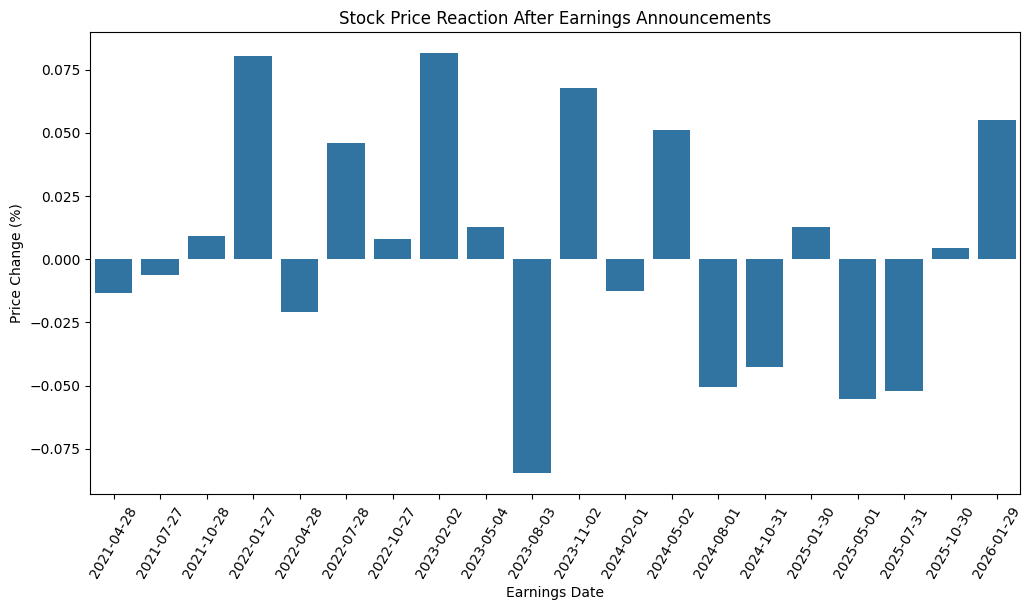

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x="earning_date",
    y="price_change",
    data=result_df
)

plt.xticks(rotation=60)
plt.title("Stock Price Reaction After Earnings Announcements")
plt.xlabel("Earnings Date")
plt.ylabel("Price Change (%)")

plt.show()


# distribution of Earning Impact

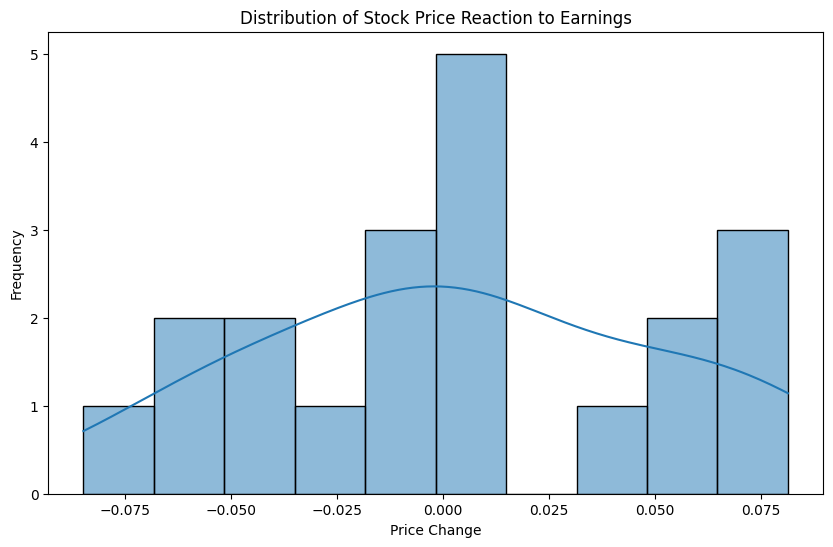

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(result_df["price_change"], bins=10, kde=True)

plt.title("Distribution of Stock Price Reaction to Earnings")
plt.xlabel("Price Change")
plt.ylabel("Frequency")

plt.show()

  # Before and After Price Comparison 

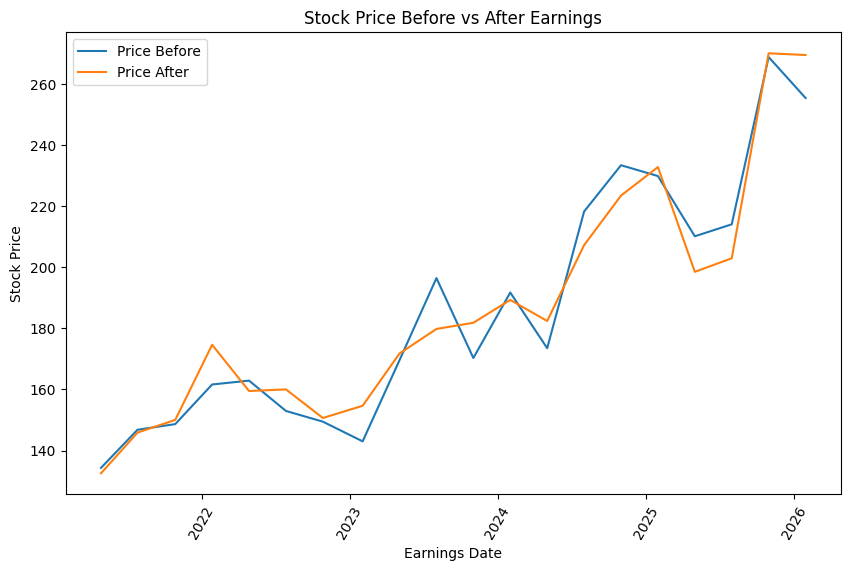

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

plt.plot(result_df["earning_date"], result_df["price_before"], label="Price Before")
plt.plot(result_df["earning_date"], result_df["price_after"], label="Price After")

plt.xticks(rotation=60)

plt.title("Stock Price Before vs After Earnings")
plt.xlabel("Earnings Date")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

# Average Marget Reaction 

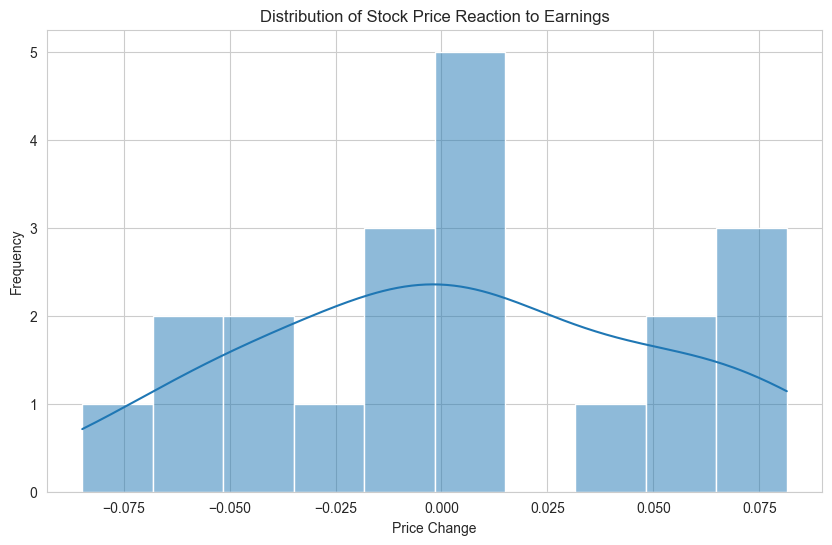

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

sns.histplot(result_df["price_change"], bins=10, kde=True)

plt.title("Distribution of Stock Price Reaction to Earnings")
plt.xlabel("Price Change")
plt.ylabel("Frequency")

plt.show()